In [2]:
import pandas as pd

df = pd.read_csv('deliveries.csv')
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
duplicates = df.duplicated(subset=['match_id', 'inning', 'over', 'ball']).sum()
print("Duplicate rows (should be 0):", duplicates)

Duplicate rows (should be 0): 0


In [7]:
balls_per_match = df.groupby('match_id').size()

max_balls = balls_per_match.max()
print("Maximum balls in a match:", max_balls)


anomalies = balls_per_match[balls_per_match > 240]

print("Matches exceeding 240 balls:", len(anomalies))
anomalies.sort_values(ascending=False).head(5)

Maximum balls in a match: 269
Matches exceeding 240 balls: 707


,0
match_id,
1216517,269
392190,267
1426268,265
1082625,263
729315,262


In [8]:
dismissals = df['dismissal_kind'].dropna().unique()
print(dismissals)

['caught' 'bowled' 'run out' 'lbw' 'retired hurt' 'stumped'
 'caught and bowled' 'hit wicket' 'obstructing the field' 'retired out']


dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64


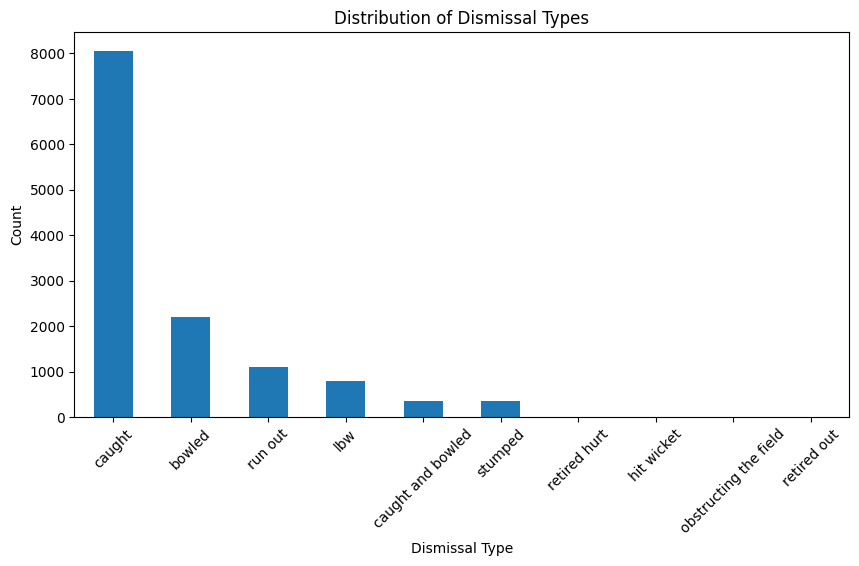

In [9]:
import matplotlib.pyplot as plt

dismissal_counts = df['dismissal_kind'].value_counts()

print(dismissal_counts)


dismissal_counts.plot(kind='bar', figsize=(10,5))
plt.title("Distribution of Dismissal Types")
plt.xlabel("Dismissal Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()